Max Fan Load Power: 33.60W


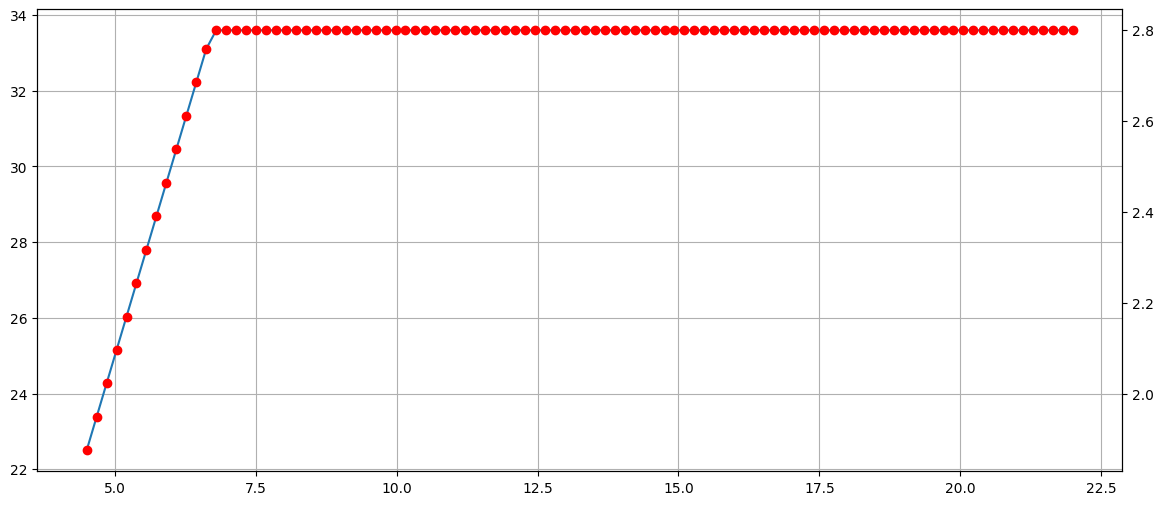

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
usb_c_v_tolerance = 0.1 # 10% tolerance
v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 100)
i_in_max = 5 # USB-C PD max current
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 8
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

input_voltage_operating_points = v_in
input_current_operating_points_max = np.full_like(input_voltage_operating_points,i_in_nom_max)
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

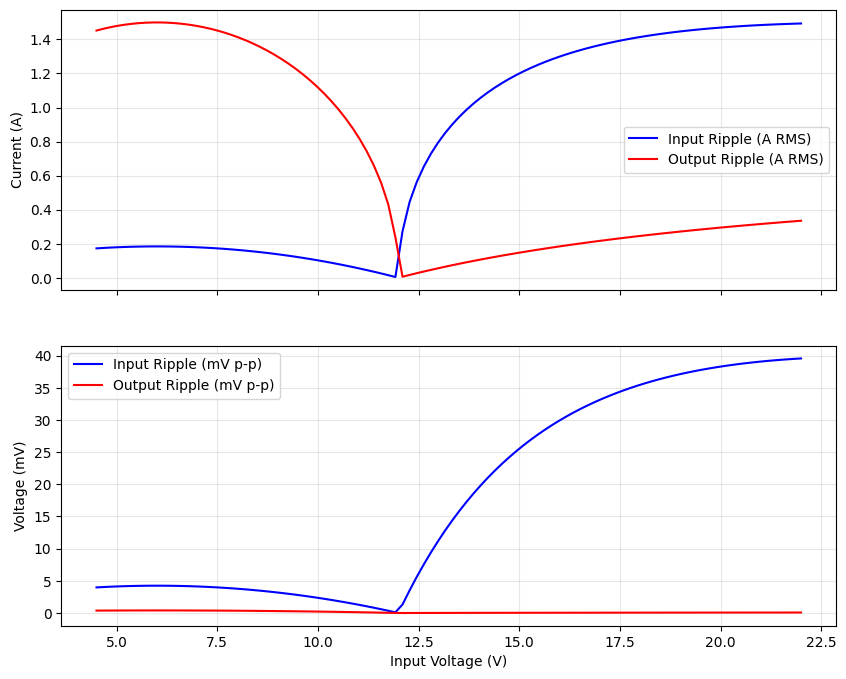

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
L = 47e-6          # Inductor Value
c_out = 4.7e-3 * 2

c_out = 4.7e-3 * 4
r_out = v_out / i_out_operating_points
duty_cycle = 1 - v_in / v_out
c_in = 47e-6 * 4       # e.g., 2x 47uF

v_in_range = np.linspace(4.5, 22.0, 100)
data = []

for v_in in v_in_range:
    # 1. Power Limit Logic
    p_in_max = v_in * i_in_nom_max
    p_out_demand = v_out * i_in_nom_max
    p_out = min(p_out_demand, p_in_max)
    i_out = p_out / v_out
    
    # 2. Ripple Calculations
    if v_in < v_out: # Boost Mode
        d = 1 - (v_in / v_out)
        delta_il = (v_in * d) / (L * f_sw)
        i_out_ripple_rms = i_out * np.sqrt(d / (1 - d))
        v_out_ripple_pp = (i_out * d) / (f_sw * c_out)
        i_in_ripple_rms = delta_il / np.sqrt(12)
        v_in_ripple_pp = delta_il / (8 * f_sw * c_in)
    else: # Buck Mode
        d = v_out / v_in
        delta_il = (v_in - v_out) * d / (L * f_sw)
        i_out_ripple_rms = delta_il / np.sqrt(12)
        v_out_ripple_pp = delta_il / (8 * f_sw * c_out)
        i_in_ripple_rms = i_out * np.sqrt(d * (1 - d))
        v_in_ripple_pp = (i_out * d * (1 - d)) / (f_sw * c_in)

    data.append({
        'Vin': v_in, 'Iout': i_out, 'Iin_Ripple_RMS': i_in_ripple_rms,
        'Iout_Ripple_RMS': i_out_ripple_rms, 'Vin_Ripple_mV': v_in_ripple_pp*1000,
        'Vout_Ripple_mV': v_out_ripple_pp*1000
    })

df = pd.DataFrame(data)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(df['Vin'], df['Iin_Ripple_RMS'], label='Input Ripple (A RMS)', color='blue')
ax1.plot(df['Vin'], df['Iout_Ripple_RMS'], label='Output Ripple (A RMS)', color='red')
ax1.set_ylabel('Current (A)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df['Vin'], df['Vin_Ripple_mV'], label='Input Ripple (mV p-p)', color='blue')
ax2.plot(df['Vin'], df['Vout_Ripple_mV'], label='Output Ripple (mV p-p)', color='red')
ax2.set_ylabel('Voltage (mV)')
ax2.set_xlabel('Input Voltage (V)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.show()